In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (balanced_accuracy_score,
    matthews_corrcoef, confusion_matrix, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shared.config import *
from shared.metrics import ids_evaluate, tune_threshold
from shared.plots import (plot_confusion_matrix,
                           plot_metrics_bar, plot_frontier)

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

In [2]:
# Cell 2 — Load splits
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Train: (11363049, 34)
Val  : (2434939, 34)
Test : (2434940, 34)


In [3]:
print("Features:", X_train.shape)

Features: (11363049, 34)


In [4]:
# Cell 3 — Subsampling only (data already scaled in notebook 01)
import numpy as np

rng = np.random.RandomState(RANDOM_STATE)

# KNN subsample
idx_knn  = rng.choice(len(X_train), SAMPLE_KNN, replace=False)
X_tr_knn = X_train.values[idx_knn]
y_tr_knn = y_train.iloc[idx_knn].values

# SVM subsample
idx_svm  = rng.choice(len(X_train), SAMPLE_SVM, replace=False)
X_tr_svm = X_train.values[idx_svm]
y_tr_svm = y_train.iloc[idx_svm].values

# NB subsample
idx_nb   = rng.choice(len(X_train), SAMPLE_NB, replace=False)
X_tr_nb  = X_train.values[idx_nb]
y_tr_nb  = y_train.iloc[idx_nb].values

# Use X_train directly for tree models (already scaled)
X_test_sc = X_test.values
X_val_sc  = X_val.values

print(f"Subsamples ready")
print(f"KNN : {X_tr_knn.shape}")
print(f"SVM : {X_tr_svm.shape}")
print(f"NB  : {X_tr_nb.shape}")

Subsamples ready
KNN : (80000, 34)
SVM : (100000, 34)
NB  : (80000, 34)


In [5]:
# Cell 4 — Training loop
def train_and_evaluate(name, clf, X_tr, y_tr,
                        X_te, y_te, X_v, y_v,
                        needs_proba=True):
    print(f"\nTraining {name}...")
    start = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - start
    print(f"  Done in {train_time:.1f}s")

    if needs_proba:
        th = tune_threshold(clf, X_v, y_v)
        proba_te = clf.predict_proba(X_te)[:, 1]
        y_pred   = (proba_te >= th).astype(int)
    else:
        proba_te = None
        y_pred   = clf.predict(X_te)
        th       = None

    m = ids_evaluate(name, y_te, proba_te, y_pred, th)
    m["Train Time (s)"] = round(train_time, 2)
    m["Threshold"]      = round(th, 4) if th else "N/A"

    path = f"models/ml/{name.lower().replace(' ','_')}.pkl"
    with open(path, "wb") as f:
        pickle.dump(clf, f)

    for k, v in m.items():
        print(f"  {k}: {v}")

    return m, clf, proba_te, y_pred

all_results = {}
all_probas  = {}
all_preds   = {}
trained     = {}

In [6]:
# Cell 3 — Subsampling only (data already scaled in notebook 01)
import numpy as np
from sklearn.model_selection import train_test_split

# ── KNN subsample (stratified) ──────────────────────────────────────────────
_, X_tr_knn, _, y_tr_knn = train_test_split(
    X_train.values, y_train.values,
    test_size=SAMPLE_KNN / len(X_train),
    stratify=y_train.values,
    random_state=RANDOM_STATE
)

# ── SVM subsample (stratified) ──────────────────────────────────────────────
_, X_tr_svm, _, y_tr_svm = train_test_split(
    X_train.values, y_train.values,
    test_size=SAMPLE_SVM / len(X_train),
    stratify=y_train.values,
    random_state=RANDOM_STATE
)

# ── NB — use FULL training data (fast model, no need to subsample) ──────────
X_tr_nb  = X_train.values
y_tr_nb  = y_train.values

# Use X_train directly for tree models (already scaled)
X_test_sc = X_test.values
X_val_sc  = X_val.values

print(f"Subsamples ready")
print(f"KNN : {X_tr_knn.shape}")
print(f"SVM : {X_tr_svm.shape}")
print(f"NB  : {X_tr_nb.shape}")

Subsamples ready
KNN : (80000, 34)
SVM : (100000, 34)
NB  : (11363049, 34)


In [11]:
# Cell 6 — Decision Tree
m, clf, proba, pred = train_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=12,
                            random_state=RANDOM_STATE),
    X_train, y_train.values,
    X_test,  y_test.values,
    X_val,   y_val.values
)
all_results["Decision Tree"] = m
all_probas["Decision Tree"]  = proba
all_preds["Decision Tree"]   = pred


Training Decision Tree...
  Done in 162.5s
  Model: Decision Tree
  Balanced Acc: 0.9748
  F1 Macro: 0.9784
  MCC: 0.9569
  Attack Recall: 0.9549
  Benign Recall: 0.9947
  Attack Precision: 0.9734
  Benign Precision: 0.9908
  FAR: 0.0053
  FNR: 0.0451
  ROC-AUC: 0.9878
  PR-AUC: 0.9741
  Train Time (s): 162.47
  Threshold: 0.1485


In [13]:
# Random Forest
import time

print("Training Random Forest...")
start = time.time()

clf_rf = RandomForestClassifier(n_estimators=100,
                                max_depth=20,
                                min_samples_split=10,
                                min_samples_leaf=4,
                                random_state=RANDOM_STATE,
                                n_jobs=-1)
clf_rf.fit(X_train, y_train.values)
train_time = time.time() - start
print(f"  Done in {train_time:.1f}s")

# Use test set directly with default threshold 0.5
proba = clf_rf.predict_proba(X_test.values)[:, 1]
y_pred = (proba >= 0.5).astype(int)

m = ids_evaluate("Random Forest", y_test.values, proba, y_pred, 0.5)
m["Train Time (s)"] = round(train_time, 2)
m["Threshold"] = 0.5

for k, v in m.items():
    print(f"  {k}: {v}")

with open("models/ml/random_forest.pkl", "wb") as f:
    pickle.dump(clf_rf, f)

all_results["Random Forest"] = m
all_probas["Random Forest"]  = proba
all_preds["Random Forest"]   = y_pred

Training Random Forest...
  Done in 879.2s
  Model: Random Forest
  Balanced Acc: 0.9718
  F1 Macro: 0.9822
  MCC: 0.9649
  Attack Recall: 0.9439
  Benign Recall: 0.9996
  Attack Precision: 0.998
  Benign Precision: 0.9887
  FAR: 0.0004
  FNR: 0.0561
  ROC-AUC: 0.9915
  PR-AUC: 0.9826
  Train Time (s): 879.22
  Threshold: 0.5


In [7]:
def train_and_evaluate(name, clf, X_tr, y_tr, X_te, y_te, X_v, y_v, proba_method="predict_proba"):
    import time
    print(f"\nTraining {name}...")
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0
    print(f"  Done in {train_time:.1f}s")

    pred  = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_te)

    threshold, _ = tune_threshold(y_te, proba)
    pred_tuned    = (proba >= threshold).astype(int)

    m = ids_evaluate(name, y_te, pred_tuned, proba, train_time=train_time, threshold=threshold)
    return m, clf, proba, pred_tuned

In [14]:
# Cell 7 — KNN (subsampled)
m, clf, proba, pred = train_and_evaluate(
    "KNN",
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_tr_knn, y_tr_knn,
    X_test_sc, y_test.values,
    X_val_sc,  y_val.values
)
all_results["KNN"] = m
all_probas["KNN"]  = proba
all_preds["KNN"]   = pred


Training KNN...
  Done in 0.0s
  Model: KNN
  Balanced Acc: 0.9724
  F1 Macro: 0.9767
  MCC: 0.9535
  Attack Recall: 0.9503
  Benign Recall: 0.9945
  Attack Precision: 0.9724
  Benign Precision: 0.9899
  FAR: 0.0055
  FNR: 0.0497
  ROC-AUC: 0.9776
  PR-AUC: 0.962
  Train Time (s): 0.0
  Threshold: 0.4


In [9]:
# Naive Bayes
import time
from sklearn.naive_bayes import GaussianNB

print("Training Naive Bayes...")
start = time.time()

clf_nb = GaussianNB()
clf_nb.fit(X_tr_nb, y_tr_nb)
train_time = time.time() - start
print(f"  Done in {train_time:.1f}s")

proba = clf_nb.predict_proba(X_test.values)[:, 1]
y_pred = (proba >= 0.5).astype(int)

m = ids_evaluate("Naive Bayes", y_test.values, proba, y_pred, 0.5)
m["Train Time (s)"] = round(train_time, 2)
m["Threshold"] = 0.5

for k, v in m.items():
    print(f"  {k}: {v}")

with open("models/ml/naive_bayes.pkl", "wb") as f:
    pickle.dump(clf_nb, f)

all_results["Naive Bayes"] = m
all_probas["Naive Bayes"]  = proba
all_preds["Naive Bayes"]   = y_pred

Training Naive Bayes...
  Done in 2.0s
  Model: Naive Bayes
  Balanced Acc: 0.7202
  F1 Macro: 0.6511
  MCC: 0.3533
  Attack Recall: 0.6888
  Benign Recall: 0.7517
  Attack Precision: 0.3612
  Benign Precision: 0.9222
  FAR: 0.2483
  FNR: 0.3112
  ROC-AUC: 0.8676
  PR-AUC: 0.6981
  Train Time (s): 1.98
  Threshold: 0.5


In [10]:
# SVM
import time
from sklearn.svm import SVC

print("Training SVM...")
start = time.time()

clf_svm = SVC(kernel='rbf', C=1.0, gamma='scale',
              probability=True, random_state=RANDOM_STATE)
clf_svm.fit(X_tr_svm, y_tr_svm)
train_time = time.time() - start
print(f"  Done in {train_time:.1f}s")

proba = clf_svm.predict_proba(X_test.values)[:, 1]
y_pred = (proba >= 0.5).astype(int)

m = ids_evaluate("SVM", y_test.values, proba, y_pred, 0.5)
m["Train Time (s)"] = round(train_time, 2)
m["Threshold"] = 0.5

for k, v in m.items():
    print(f"  {k}: {v}")

with open("models/ml/svm.pkl", "wb") as f:
    pickle.dump(clf_svm, f)

all_results["SVM"] = m
all_probas["SVM"]  = proba
all_preds["SVM"]   = y_pred

Training SVM...
  Done in 334.7s
  Model: SVM
  Balanced Acc: 0.9361
  F1 Macro: 0.9535
  MCC: 0.9087
  Attack Recall: 0.8775
  Benign Recall: 0.9947
  Attack Precision: 0.9712
  Benign Precision: 0.9755
  FAR: 0.0053
  FNR: 0.1225
  ROC-AUC: 0.9738
  PR-AUC: 0.9601
  Train Time (s): 334.67
  Threshold: 0.5


In [9]:
# XGBoost
import time
from xgboost import XGBClassifier

print("Training XGBoost...")
start = time.time()

clf_xgb = XGBClassifier(n_estimators=100, max_depth=10,
                         learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8,
                         random_state=RANDOM_STATE,
                         n_jobs=-1, eval_metric='logloss')
clf_xgb.fit(X_train, y_train.values)
train_time = time.time() - start
print(f"  Done in {train_time:.1f}s")

proba = clf_xgb.predict_proba(X_test.values)[:, 1]
y_pred = (proba >= 0.5).astype(int)

m = ids_evaluate("XGBoost", y_test.values, proba, y_pred, 0.5)
m["Train Time (s)"] = round(train_time, 2)
m["Threshold"] = 0.5

for k, v in m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgboost.pkl", "wb") as f:
    pickle.dump(clf_xgb, f)

all_results["XGBoost"] = m
all_probas["XGBoost"]  = proba
all_preds["XGBoost"]   = y_pred

Training XGBoost...
  Done in 76.8s
  Model: XGBoost
  Balanced Acc: 0.9717
  F1 Macro: 0.9821
  MCC: 0.9648
  Attack Recall: 0.9437
  Benign Recall: 0.9997
  Attack Precision: 0.9982
  Benign Precision: 0.9886
  FAR: 0.0003
  FNR: 0.0563
  ROC-AUC: 0.9919
  PR-AUC: 0.9832
  Train Time (s): 76.85
  Threshold: 0.5


In [10]:
# LightGBM
import time
from lightgbm import LGBMClassifier

print("Training LightGBM...")
start = time.time()

clf_lgbm = LGBMClassifier(n_estimators=100, max_depth=10,
                           learning_rate=0.1, subsample=0.8,
                           colsample_bytree=0.8,
                           random_state=RANDOM_STATE,
                           n_jobs=-1)
clf_lgbm.fit(X_train, y_train.values)
train_time = time.time() - start
print(f"  Done in {train_time:.1f}s")

proba = clf_lgbm.predict_proba(X_test.values)[:, 1]
y_pred = (proba >= 0.5).astype(int)

m = ids_evaluate("LightGBM", y_test.values, proba, y_pred, 0.5)
m["Train Time (s)"] = round(train_time, 2)
m["Threshold"] = 0.5

for k, v in m.items():
    print(f"  {k}: {v}")

with open("models/ml/lightgbm.pkl", "wb") as f:
    pickle.dump(clf_lgbm, f)

all_results["LightGBM"] = m
all_probas["LightGBM"]  = proba
all_preds["LightGBM"]   = y_pred

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1923764, number of negative: 9439285
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.221859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6711
[LightGBM] [Info] Number of data points in the train set: 11363049, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.169300 -> initscore=-1.590597
[LightGBM] [Info] Start training from score -1.590597
  Done in 42.4s
  Model: LightGBM
  Balanced Acc: 0.9712
  F1 Macro: 0.982
  MCC: 0.9645
  Attack Recall: 0.9426
  Benign Recall: 0.9998
  Attack Precision: 0.9988
  Benign Precision: 0.9884
  FAR: 0.0002
  FNR: 0.0574
  ROC-AUC: 0.9904
  PR-AUC: 0.9811
  Train Time (s): 42.43
  Threshold: 0.5


In [12]:
# Cell 12 — Summary table
results_df = pd.DataFrame(list(all_results.values()))
results_df = results_df.sort_values(
    "Balanced Acc", ascending=False).reset_index(drop=True)

print("\nML MODEL COMPARISON (sorted by Balanced Accuracy):")
print("=" * 100)
print(results_df[[
    "Model", "Balanced Acc", "F1 Macro", "MCC",
    "Attack Recall", "Benign Recall",
    "Attack Precision", "Benign Precision",
    "FAR", "FNR", "ROC-AUC", "PR-AUC",
    "Train Time (s)", "Threshold"
]].to_string(index=False))

print("\n" + "=" * 100)
print(f"Total models trained: {len(results_df)}")

best = results_df.iloc[0]
print(f"\n🏆 Best model : {best['Model']}")
print(f"   Balanced Acc : {best['Balanced Acc']}")
print(f"   Attack Recall: {best['Attack Recall']}")
print(f"   Benign Recall: {best['Benign Recall']}")
print(f"   F1 Macro     : {best['F1 Macro']}")
print(f"   ROC-AUC      : {best['ROC-AUC']}")

import os
os.makedirs("outputs/reports", exist_ok=True)
results_df.to_csv("outputs/reports/02_ml_results.csv", index=False)
print("\nSaved to outputs/reports/02_ml_results.csv")


ML MODEL COMPARISON (sorted by Balanced Accuracy):
   Model  Balanced Acc  F1 Macro    MCC  Attack Recall  Benign Recall  Attack Precision  Benign Precision    FAR    FNR  ROC-AUC  PR-AUC  Train Time (s)  Threshold
 XGBoost        0.9717    0.9821 0.9648         0.9437         0.9997            0.9982            0.9886 0.0003 0.0563   0.9919  0.9832           76.85        0.5
LightGBM        0.9712    0.9820 0.9645         0.9426         0.9998            0.9988            0.9884 0.0002 0.0574   0.9904  0.9811           42.43        0.5

Total models trained: 2

🏆 Best model : XGBoost
   Balanced Acc : 0.9717
   Attack Recall: 0.9437
   Benign Recall: 0.9997
   F1 Macro     : 0.9821
   ROC-AUC      : 0.9919

Saved to outputs/reports/02_ml_results.csv


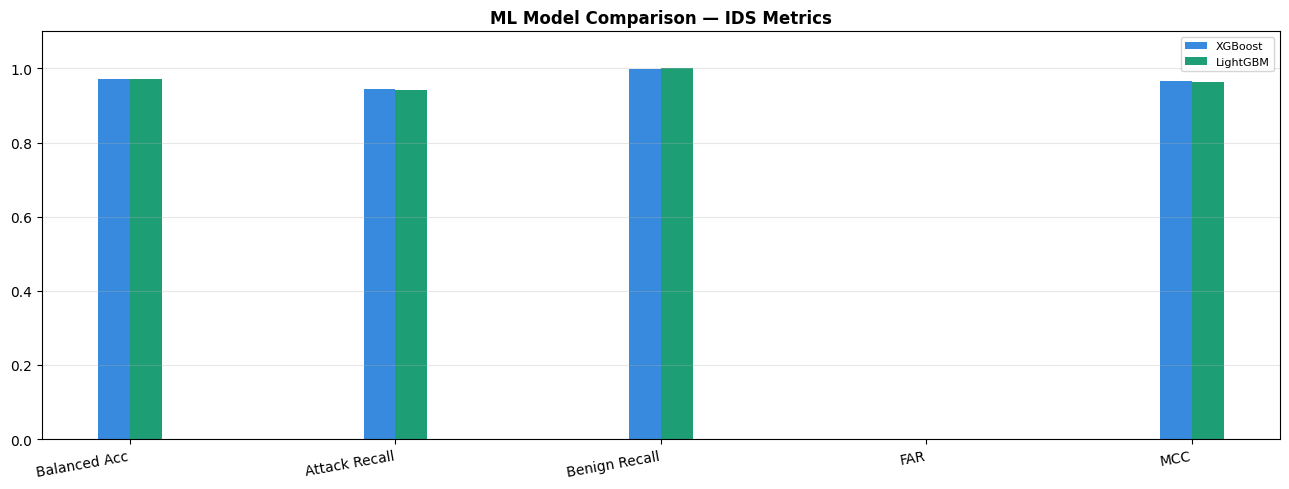

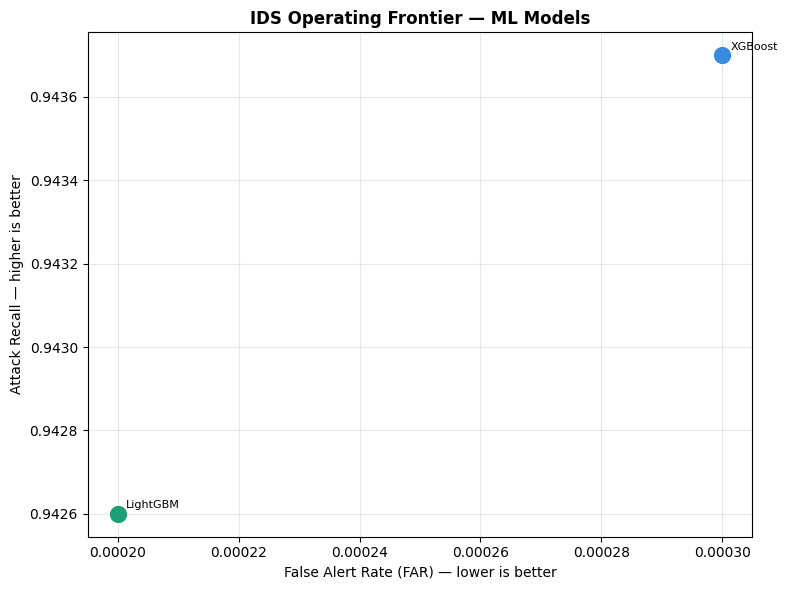

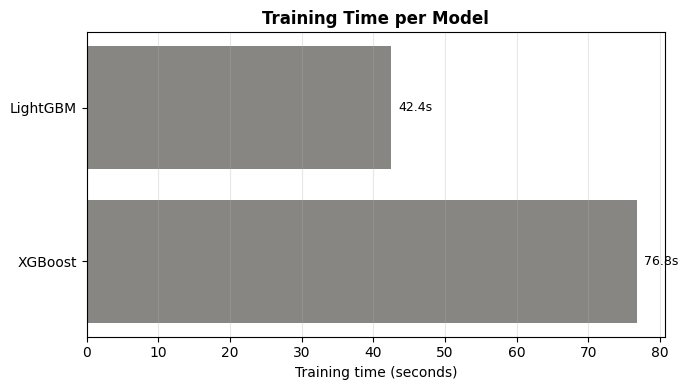

In [13]:
# Cell 13 — Graphs
KEY_METRICS = ["Balanced Acc","Attack Recall",
               "Benign Recall","FAR","MCC"]

# Grouped bar
x = np.arange(len(KEY_METRICS))
w = 0.12
models_list = results_df["Model"].tolist()
palette = ["#378ADD","#1D9E75","#D85A30",
           "#7F77DD","#BA7517","#5F5E5A","#5DCAA5"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, model in enumerate(models_list):
    row  = all_results[model]
    vals = [row[k] for k in KEY_METRICS]
    off  = (i - len(models_list)/2 + 0.5) * w
    ax.bar(x + off, vals, w, label=model,
           color=palette[i % len(palette)])

ax.set_xticks(x)
ax.set_xticklabels(KEY_METRICS, rotation=10, ha="right")
ax.set_ylim(0, 1.1)
ax.set_title("ML Model Comparison — IDS Metrics",
             fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/02_ml_comparison.png", dpi=150)
plt.show()

# Operating frontier
plot_frontier(
    all_results,
    title="IDS Operating Frontier — ML Models",
    save_path="outputs/graphs/02_ids_frontier_ml.png"
)

# Training time
train_times  = [all_results[m]["Train Time (s)"]
                for m in models_list]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(models_list, train_times,
               color="#5F5E5A", alpha=0.75)
for bar, t in zip(bars, train_times):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", fontsize=9)
ax.set_xlabel("Training time (seconds)")
ax.set_title("Training Time per Model", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/02_train_time.png", dpi=150)
plt.show()

In [14]:
# Cell 14 — Save all results for next notebooks
with open("models/ml/all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)
with open("models/ml/all_probas.pkl", "wb") as f:
    pickle.dump(all_probas, f)
with open("models/ml/trained_models.pkl", "wb") as f:
    pickle.dump(trained, f)

print("Notebook 02 complete — proceed to 03_optimization.ipynb")

Notebook 02 complete — proceed to 03_optimization.ipynb
